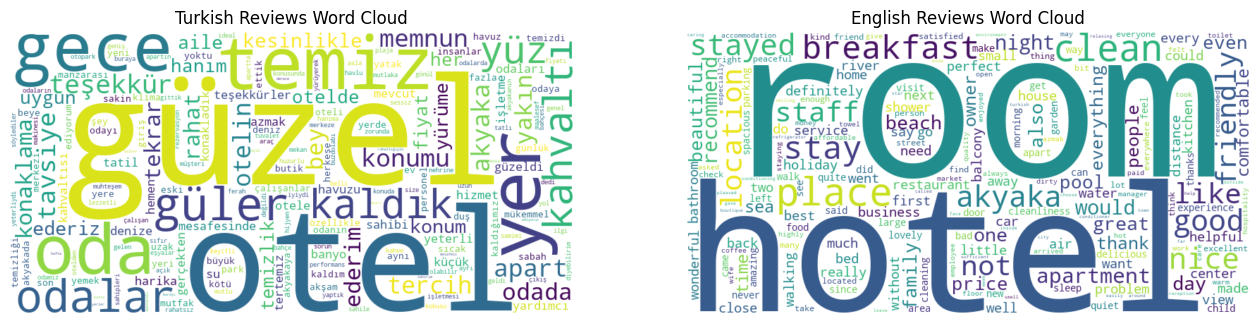

In [1]:
import pandas as pd
from langdetect import detect
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

csv_path = r"C:\Users\catsu\PycharmProjects\scrappyhotel\final_processed_reviews_no_spellcheck.csv"

df = pd.read_csv(csv_path, engine="python")

if "processed_reviews" in df.columns:
    reviews = df["processed_reviews"].dropna().tolist()
elif "processed_review" in df.columns:
    reviews = df["processed_review"].dropna().tolist()
else:
    raise ValueError("CSV'de 'processed_reviews' veya 'processed_review' sütunu bulunamadı!")

turkish_texts = []
english_texts = []

for review in reviews:
    try:
        lang = detect(review)
    except Exception as e:
        lang = "unknown"
    if lang == "tr":
        turkish_texts.append(review)
    elif lang == "en":
        english_texts.append(review)

turkish_combined = " ".join(turkish_texts)
english_combined = " ".join(english_texts)

turkish_tokens = turkish_combined.split()
english_tokens = english_combined.split()

turkish_freq = Counter(turkish_tokens)
english_freq = Counter(english_tokens)

turkish_wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis') \
                .generate_from_frequencies(turkish_freq)
english_wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis') \
                .generate_from_frequencies(english_freq)

plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(turkish_wc, interpolation='bilinear')
plt.axis("off")
plt.title("Turkish Reviews Word Cloud")

plt.subplot(1, 2, 2)
plt.imshow(english_wc, interpolation='bilinear')
plt.axis("off")
plt.title("English Reviews Word Cloud")

plt.show()


In [2]:
!pip install langdetect



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
